<a href="https://colab.research.google.com/github/amiralirh/Diabetic-Retinopathy-Detection/blob/main/DR_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetic Retinopathy Detection: Automated Image Classification using Deep Learning

## 1. Project Overview and Objective
Diabetic Retinopathy (DR) is a leading cause of blindness globally, particularly among working-age populations. Early detection and treatment are critical to preventing irreversible vision loss. However, manual screening is highly resource-intensive and requires specialized ophthalmologic expertise, which is often scarce in rural or under-resourced areas.

The objective of this project is to build a robust applied pipeline to automate the detection and grading of Diabetic Retinopathy from color fundus photography. By leveraging deep learning techniques, this model aims to assist clinicians by providing rapid, scalable, and accurate diagnostic screening.

## 2. Dataset Characteristics
This project utilizes the **APTOS 2019 Blindness Detection dataset**, provided by the Aravind Eye Hospital in India. The dataset consists of high-resolution retinal images captured under various imaging conditions.

Each image is evaluated by a clinician and rated on a severity scale of 0 to 4:
* **0 - No DR:** Healthy retina with no abnormalities.
* **1 - Mild:** Presence of microaneurysms.
* **2 - Moderate:** Presence of multiple microaneurysms, dot-and-blot hemorrhages, or venous beading.
* **3 - Severe:** Significant hemorrhages, venous beading, or intraretinal microvascular abnormalities (IRMA).
* **4 - Proliferative DR:** Advanced stage characterized by neovascularization (new abnormal blood vessel growth) or vitreous/preretinal hemorrhage.

*Note: Real-world medical datasets like APTOS often feature severe class imbalance, varying resolutions, and artifacts (e.g., lighting discrepancies, out-of-focus areas), which necessitate rigorous image preprocessing.*

## 3. Evaluation Metric
The primary performance metric for this classification task is the **Quadratic Weighted Kappa (QWK)**.
Unlike standard accuracy, QWK measures the agreement between two ratings and heavily penalizes predictions that are further away from the true class. For example, misclassifying a "Severe" (Class 3) case as "Mild" (Class 1) incurs a much higher penalty than misclassifying it as "Moderate" (Class 2). This mathematically aligns the model's objective with clinical risk assessment.

## 4. Technical Approach
To address the inherent challenges of this medical dataset, the workflow is structured into the following phases:
1. **Exploratory Data Analysis (EDA):** Assessing class distribution, image dimensions, and visual characteristics of each DR grade.
2. **Advanced Image Preprocessing:** Cropping uninformative borders, resizing, and applying filtering techniques to enhance the visibility of blood vessels, exudates, and microaneurysms.
3. **Data Augmentation:** Applying geometric and photometric transformations to improve model generalization.
4. **Model Architecture & Transfer Learning:** Utilizing a Convolutional Neural Network (CNN) architecture designed for robust feature extraction.
5. **Training & Optimization:** Fine-tuning the network using appropriate loss functions and optimization algorithms.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import class_weight
from tensorflow.keras.models import Model as KerasModel



##  Directory Configuration and Data Transfer


In [ ]:
# --- Dataset Path Configuration ---



# --- Define Source Paths in Google Drive ---
SOURCE_DATA_DIR_ON_DRIVE = '/content/drive/MyDrive/Aptos'


# --- Define Destination Paths in Colab Local Storage ---
LOCAL_DATA_DIR_ON_COLAB = '/content/aptos_local_data' # Folder name to copy data in Colab
LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'preprocessed_train_images')
LOCAL_TEST_IMAGES_DIR = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'test_images')

# --- Copying Data from Google Drive to Colab Local Storage ---
print(f"Copying data from Google Drive ({SOURCE_DATA_DIR_ON_DRIVE}) to Colab local storage ({LOCAL_DATA_DIR_ON_COLAB})...")

# Create destination folders in Colab local storage
os.makedirs(LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR, exist_ok=True)
os.makedirs(LOCAL_TEST_IMAGES_DIR, exist_ok=True) # For test images

# Copy preprocessed training images folder
# We use rsync -avh which is usually faster and more stable than cp -r in Colab
!rsync -avh "$SOURCE_DATA_DIR_ON_DRIVE/preprocessed_train_images/" "$LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR/"

# Copy test images folder (for final prediction)
!rsync -avh "$SOURCE_DATA_DIR_ON_DRIVE/test_images/" "$LOCAL_TEST_IMAGES_DIR/"

# Copy CSV files
!cp "$SOURCE_DATA_DIR_ON_DRIVE/train.csv" "$LOCAL_DATA_DIR_ON_COLAB/train.csv"
!cp "$SOURCE_DATA_DIR_ON_DRIVE/test.csv" "$LOCAL_DATA_DIR_ON_COLAB/test.csv"

print("Data copying to Colab local storage completed.")

# --- Now your paths refer to Colab local folders ---
train_csv_path = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'train.csv')
preprocessed_train_image_dir = LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR

test_csv_path = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'test.csv')
test_image_dir = LOCAL_TEST_IMAGES_DIR

# --- 1. Data Loading and Preprocessing ---

# Read training CSV file
df_train = pd.read_csv(train_csv_path)
df_train['id_code'] = df_train['id_code'].apply(lambda x: x + '.png')

# Display some data samples and class distribution
print("Training DataFrame:")
print(df_train.head())
print("\nClass Distribution in Training Data:")
print(df_train['diagnosis'].value_counts().sort_index())

##  Data Split

To accurately evaluate the model's ability to generalize to unseen data, we must partition our dataset into a training set and a validation holdout set.

This cell utilizes Scikit-Learn's `train_test_split` function to allocate 80% of the images for model training and reserve 20% for validation.

**The Importance of Stratification:**
The APTOS dataset suffers from severe class imbalance, with a vast majority of healthy retinas (Class 0) and very few severe cases (Classes 3 and 4). If we were to split the data randomly, we run the risk of creating a validation set that contains zero examples of the minority classes.

By enforcing `stratify=df_train['diagnosis']`, we guarantee that the original distribution of Diabetic Retinopathy severity grades is perfectly preserved in both the training and validation sets. This ensures our evaluation metrics during training accurately reflect the model's performance across all stages of the disease. A fixed `random_state` is also set to ensure experimental reproducibility.

In [ ]:
# Split training data into train and validation sets
train_df, val_df = train_test_split(df_train,
                                    test_size=0.2, # 20% for validation
                                    stratify=df_train['diagnosis'],
                                    random_state=42)

print(f"\nNumber of training images: {len(train_df)}")
print(f"Number of validation images: {len(val_df)}")


تعداد تصاویر آموزشی: 2929
تعداد تصاویر اعتبارسنجی: 733


##  Data Pipeline and Augmentation (tf.data)

To maximize GPU utilization and ensure smooth, bottleneck-free training, this cell constructs a highly optimized Extract-Transform-Load (ETL) pipeline using the `tf.data.Dataset` API. Rather than loading all images into RAM at once, this approach dynamically reads, processes, and batches data on the CPU while the GPU is busy training the previous batch.

**Key Components of the Pipeline:**

* **Data Loading and Formatting:** Images are read from disk, decoded, resized to the target tensor dimensions (224x224), and normalized using a specific `preprocess_input` function (which scales pixel values to the range expected by our chosen pre-trained architecture).
* **Targeted Data Augmentation:** A custom augmentation function applies random transformations to artificially expand the training dataset and prevent overfitting.
    * **Geometric:** Random horizontal/vertical flips and 90-degree rotations are applied, which are biologically plausible for retinal images.
    * **Photometric:** Slight, conservative adjustments to brightness (±10%) and contrast (±10%) are introduced. *Crucially, hue and saturation shifts have been removed.* In medical imaging, the specific color of a lesion (e.g., bright yellow hard exudates vs. dark red hemorrhages) carries vital diagnostic information; altering the hue could inadvertently destroy these clinical features.
* **Pipeline Optimization:**
    * `.map(num_parallel_calls=tf.data.AUTOTUNE)`: Parallelizes the preprocessing and augmentation steps across available CPU cores.
    * `.cache()`: Stores the preprocessed images in memory after the first epoch, eliminating disk I/O latency for all subsequent epochs.
    * `.prefetch(tf.data.AUTOTUNE)`: The most critical optimization; it prepares the next batch of data in the background while the current batch is being processed by the GPU.

**Addressing Class Imbalance via Cost-Sensitive Learning:**
The APTOS dataset is notoriously skewed towards healthy retinas. To prevent the model from simply predicting "Class 0" for every image and achieving a misleadingly high accuracy, we define a **Custom Class Weights Dictionary**.
By assigning a much higher penalty weight to the severe minority classes (Classes 1-4) and a lower weight to the dominant Class 0 (0.40), we force the loss function to heavily prioritize learning the features of the diseased retinas, directly addressing issues identified in prior confusion matrix analyses.

In [ ]:
# --- Image Parameters ---
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

# --- Function to load and preprocess an image (for tf.data.Dataset) ---
# This function reads images and applies preprocess_input.
def load_and_preprocess_image_tf(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = tf.cast(img, tf.float32) # Convert to float32
    img = preprocess_input(img)

    return img, label

# --- Data augmentation function for tf.data.Dataset (random transformations with tf.image) ---
def augment_data_tf(image, label):
    # Geometric transformations (unchanged)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # === Changes: Revert to balanced Data Augmentation ===
    image = tf.image.random_brightness(image, max_delta=0.1) # Reduced from 0.15 to 0.1
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1) # Reduced from [0.8, 1.2] to [0.9, 1.1]
    # random_hue and random_saturation have been removed (for simplicity and stability)


    return image, label

# Create list of file paths and labels
train_image_paths = [os.path.join(preprocessed_train_image_dir, img_id) for img_id in train_df['id_code'].values]
train_labels = train_df['diagnosis'].values

val_image_paths = [os.path.join(preprocessed_train_image_dir, img_id) for img_id in val_df['id_code'].values]
val_labels = val_df['diagnosis'].values

# Build Dataset from file paths
train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_labels))

# Map load_and_preprocess_image_tf function to each element of the Dataset
train_dataset = train_dataset.map(
    load_and_preprocess_image_tf,
    num_parallel_calls=tf.data.AUTOTUNE
)
validation_dataset = validation_dataset.map(
    load_and_preprocess_image_tf,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Apply data augmentation (only on the training set)
train_dataset = train_dataset.map(
    augment_data_tf,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Cache the dataset in memory (very important for speed)
train_dataset = train_dataset.cache()
validation_dataset = validation_dataset.cache()

# Batching, Shuffling, and Prefetching
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\nDatasets successfully created from file paths with internal Data Augmentation (tf.data).")
# --- Calculate Class Weights ---
# These weights are adjusted based on confusion matrix analysis (improved).
class_weights_dict = {
    0: 0.40,
    1: 7.0,
    2: 6.0,
    3: 8.0,
    4: 6.0
}
print("\nCustomized weights for each class:")
print(class_weights_dict)


Datasets با موفقیت از مسیرهای فایل و با Data Augmentation داخلی (tf.data) ایجاد شدند.

وزن های سفارشی شده برای هر کلاس:
{0: 0.4, 1: 7.0, 2: 6.0, 3: 8.0, 4: 6.0}


##  Model Architecture and Transfer Learning (ResNet50)

Training a deep Convolutional Neural Network (CNN) from scratch on a specialized medical dataset often leads to severe overfitting, as the model has too many parameters relative to the number of available images. To mitigate this, this step implements **Transfer Learning** using the **ResNet50** architecture, leveraging its robust feature extraction capabilities pre-trained on the massive ImageNet dataset.

**Architectural Configuration and Strategy:**

* **Feature Extractor (Base Model):** We instantiate ResNet50 without its original classification head (`include_top=False`). Crucially, we **freeze** all weights in these base layers. This preserves the network's foundational ability to detect edges, textures, and basic patterns, and prevents these valuable weights from being scrambled by large, random gradient updates during the initial training phase.
* **Custom Classification Head:** To adapt the model to our specific 5-class Diabetic Retinopathy task, we construct a new, lightweight top layer sequence:
    * **Global Average Pooling 2D (GAP):** Condenses the spatial dimensions of the final feature maps into a single 1D vector. GAP acts as a strong structural regularizer and is significantly less prone to overfitting than a traditional `Flatten` layer.
    * **Dense Layer (256 Units):** A fully connected layer with a ReLU activation function to learn the complex, non-linear combinations of the extracted retinal features.
    * **Aggressive Dropout (0.5):** To actively combat the network's tendency to memorize the training data, a high dropout rate of 50% is enforced. This randomly disables half of the neurons during each training step, forcing the network to learn redundant, robust representations of DR biomarkers.
    * **Output Layer:** A final Dense layer with a `softmax` activation function to output a normalized probability distribution across the 5 DR severity grades.

**Model Compilation:**
The customized network is compiled using the **Adam optimizer** with a standard initial learning rate of `0.001`. The loss function is set to **Sparse Categorical Crossentropy**, which is the mathematically correct choice since our dataset labels are mutually exclusive integers (0, 1, 2, 3, 4) rather than one-hot encoded vectors.

In [ ]:

# --- 2. Model Design and Construction ---

# Load pre-trained ResNet50 model on ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Freeze base layers (for initial training): This prevents ResNet50 weights from changing initially
for layer in base_model.layers:
    layer.trainable = False

# --- 2. Model Design and Construction ---


# Add new layers for our specific problem
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5) # <--- Change: Dropout rate increased from 0.2 or 0.3 (default) to 0.5
predictions = Dense(NUM_CLASSES, activation='softmax')(x)


# Build the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model for initial training
initial_learning_rate = 0.001
model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f"\n--- Model Summary (Initial Training) ---")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- خلاصه مدل (آموزش اولیه) ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


##  Two-Phase Training Strategy and Dynamic Optimization

Training a transfer learning model effectively on medical imagery requires a carefully staged approach. If we were to train the entire network immediately, the large gradient updates originating from our initially randomized classification head would propagate backwards, destroying the valuable feature-extraction weights learned from ImageNet (a phenomenon known as catastrophic forgetting).

This cell implements a rigorous, two-phase training protocol to safely adapt the network to our retinal dataset.

**Phase 1: Classification Head Warm-up (Initial Training)**
* For the first 10 epochs, the ResNet50 base remains strictly **frozen**.
* The optimizer updates only the weights of our newly added Dense layers.
* This stabilizes the classification head, allowing it to align with the extracted ImageNet features without disturbing the foundational convolutional filters.
* We pass our `class_weights_dict` to ensure the model heavily penalizes errors on the underrepresented severe cases right from the start.

**Phase 2: End-to-End Fine-Tuning**
* Once the top layers have achieved a baseline proficiency, the entire network is **unfrozen** (`layer.trainable = True`).
* The model is recompiled with a drastically **lower learning rate** (`1e-05`).
* During these final 15 epochs, the optimizer makes precise micro-adjustments across the entire network, shifting the convolutional filters away from recognizing generic objects (like dogs or cars) and toward recognizing specific retinal biomarkers (like hemorrhages and exudates).

**Dynamic Training Controls (Callbacks)**
To automate the training lifecycle and prevent overfitting, we employ two highly tuned monitoring callbacks:
* **Early Stopping (`patience=20`):** Monitors `val_accuracy`. The extended patience of 20 epochs gives the model ample time to push through temporary training plateaus or noisy loss landscapes—which are very common in highly augmented medical data—before halting. It guarantees we exit with the optimal model state via `restore_best_weights=True`.
* **Learning Rate Decay (`ReduceLROnPlateau`, `patience=15`):** If validation accuracy stagnates for 15 epochs, the learning rate is halved (`factor=0.5`). This allows the model to take progressively smaller steps in the parameter space, helping it settle into narrower, more optimal minima without overshooting.

In [ ]:
# --- 3. Model Training ---

# Callbacks (with tuned values for deeper convergence)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max', verbose=1) # <--- patience for EarlyStopping increased to 20
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=15, min_lr=1e-08, mode='max', verbose=1) # <--- patience for ReduceLROnPlateau increased to 15

EPOCHS_INITIAL = 10
print(f"\n--- Starting Initial Training for {EPOCHS_INITIAL} Epochs ---")
history_initial = model.fit(
    train_dataset,
    epochs=EPOCHS_INITIAL,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

print("\n--- Starting Fine-tuning Phase ---")

for layer in base_model.layers:
    layer.trainable = True

fine_tune_learning_rate = 1e-05
model.compile(optimizer=Adam(learning_rate=fine_tune_learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f"\nModel recompiled with learning rate {fine_tune_learning_rate} for Fine-tuning.")
print(f"--- Model Summary (after Fine-tuning) ---")
model.summary()

EPOCHS_FINE_TUNE = 15

print(f"\nStarting Fine-tuning for {EPOCHS_FINE_TUNE} Epochs...")
history_fine_tune = model.fit(
    train_dataset,
    epochs=EPOCHS_FINE_TUNE,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

print("\n--- Fine-tuning Phase Completed ---")


--- شروع آموزش اولیه برای 10 Epoch ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 281ms/step - accuracy: 0.3415 - loss: 6.4510 - val_accuracy: 0.6398 - val_loss: 1.0599 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.6032 - loss: 3.8488 - val_accuracy: 0.5948 - val_loss: 1.0953 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6364 - loss: 3.7240 - val_accuracy: 0.6876 - val_loss: 0.8758 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.6539 - loss: 3.4976 - val_accuracy: 0.7162 - val_loss: 0.7887 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.6864 - loss: 3.3794 - val_accuracy: 0.6794 - val_loss: 0.8954 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.6925 - loss: 3.2640 - val_accuracy: 0.6726 - val_loss: 0.9608 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 10

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 24,060,421 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)


در حال شروع Fine-tuning برای 15 Epoch...
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 119s 650ms/step - accuracy: 0.6356 - loss: 4.5020 - val_accuracy: 0.7244 - val_loss: 0.7788 - learning_rate: 1.0000e-05
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - accuracy: 0.7092 - loss: 2.8587 - val_accuracy: 0.7653 - val_loss: 0.7200 - learning_rate: 1.0000e-05
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 301ms/step - accuracy: 0.7897 - loss: 2.2163 - val_accuracy: 0.7613 - val_loss: 0.7531 - learning_rate: 1.0000e-05
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 309ms/step - accuracy: 0.8408 - loss: 1.7117 - val_accuracy: 0.7708 - val_loss: 0.7444 - learning_rate: 1.0000e-05
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 306ms/step - accuracy: 0.8753 - loss: 1.3757 - val_accuracy: 0.7899 - val_loss: 0.7909 - learning_rate: 1.0000e-05
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 311ms/step - accuracy: 0.9106 - loss: 1.0478 - val_accuracy: 0.7735 - val_loss: 0.8184 - learning_rate: 1.0000e-05
Epoch 7/15
92/9

##  Comprehensive Model Evaluation and Feature Visualization

Once fine-tuning is complete, it is critical to evaluate the model from multiple analytical and clinical perspectives. Accuracy alone is an insufficient metric for imbalanced medical datasets. This final cell executes a rigorous evaluation suite to measure the model's true diagnostic capability, its error distribution, and the quality of the internal features it has learned.

**1. Training Dynamics (Learning Curves)**
We begin by plotting the accuracy and loss curves over the fine-tuning epochs. Analyzing the divergence between the training and validation lines allows us to diagnose overfitting or underfitting, confirming whether our Early Stopping and Learning Rate schedules functioned as intended.

**2. Clinical Error Analysis (Confusion Matrix & Classification Report)**
* **Classification Report:** Provides granular metrics (Precision, Recall, and F1-Score) for each specific DR grade. We pay special attention to the Recall of minority classes (Classes 3 and 4) to ensure the network is not just defaulting to majority predictions.
* **Confusion Matrix:** In clinical staging, the *type* of error matters. Misclassifying a "Mild" case as "Moderate" is a minor error, but misclassifying "Proliferative DR" as "Healthy" is a catastrophic failure. The heatmap allows us to visualize exactly where the model is confused and verify if its errors are safely constrained to adjacent severity grades.

**3. Official Competition Metric (Quadratic Weighted Kappa)**
We calculate the **Cohen's Kappa Score** with `weights='quadratic'`. This is the gold-standard metric for the APTOS competition. It mathematically penalizes predictions that are further away from the true class, perfectly aligning the model's evaluation with the real-world clinical risk of misdiagnosis.

**4. Receiver Operating Characteristic (ROC-AUC)**
To measure the model's ability to distinguish between individual classes, we binarize the labels and plot the Multi-Class ROC curve. An AUC (Area Under the Curve) score closer to 1.0 indicates excellent class separation. High AUC scores across all classes prove that the model has learned distinct, separable representations for each stage of the disease.

**5. Latent Space Visualization (t-SNE)**
Deep neural networks can sometimes act as "black boxes." To ensure the model is learning meaningful biological features rather than memorizing noise, we extract the high-dimensional feature vectors from the final pooling layer and compress them into 2 dimensions using **t-Distributed Stochastic Neighbor Embedding (t-SNE)**.
* A successful t-SNE plot should reveal distinct color clusters, indicating that the CNN correctly groups images of similar DR severity together.
* Ideally, we should observe a continuous manifold or progression from Class 0 (Healthy) through to Class 4 (Proliferative), mirroring the biological progression of the disease.

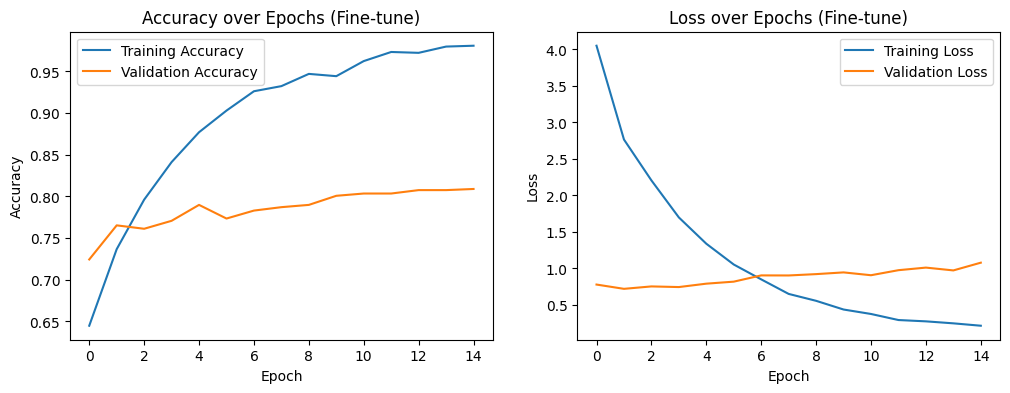


--- ارزیابی نهایی مدل ---
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 303ms/step

گزارش طبقه‌بندی نهایی:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       361
           1       0.54      0.39      0.45        74
           2       0.68      0.93      0.79       200
           3       0.62      0.33      0.43        39
           4       0.77      0.34      0.47        59

    accuracy                           0.81       733
   macro avg       0.71      0.59      0.62       733
weighted avg       0.81      0.81      0.79       733



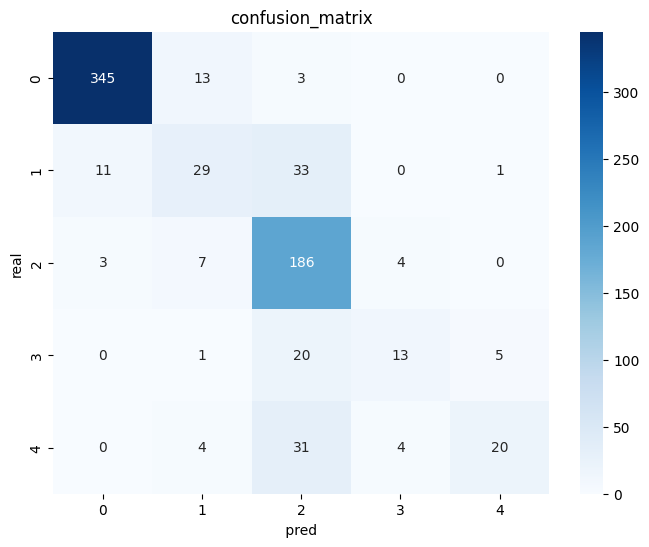


Cohen's Kappa Score (Quadratic) نهایی: 0.8657


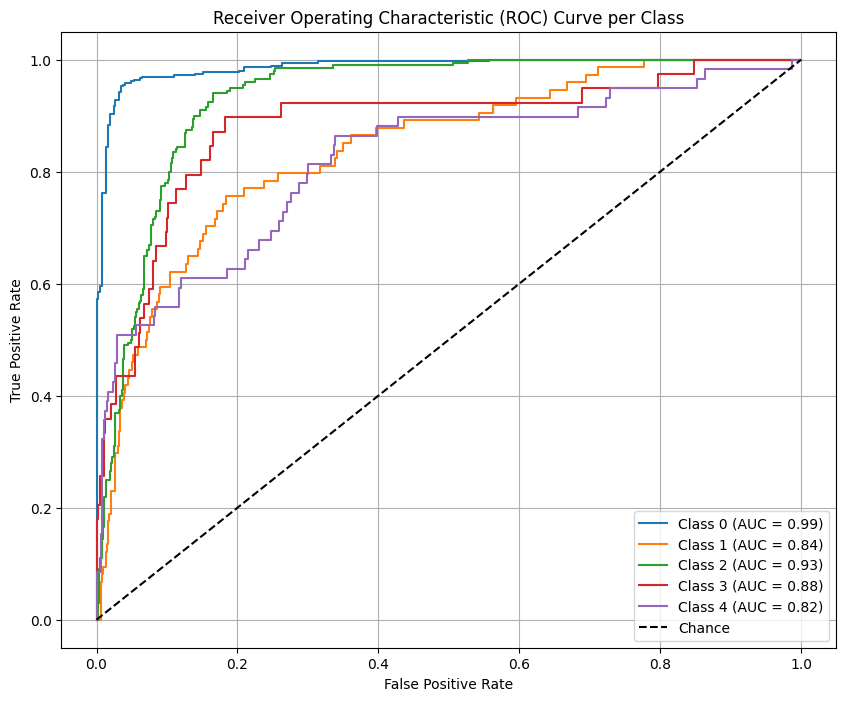


AUC Scores per Class:
Class 0: 0.9868
Class 1: 0.8411
Class 2: 0.9330
Class 3: 0.8836
Class 4: 0.8200

--- شروع بصری‌سازی ویژگی‌ها با t-SNE ---
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


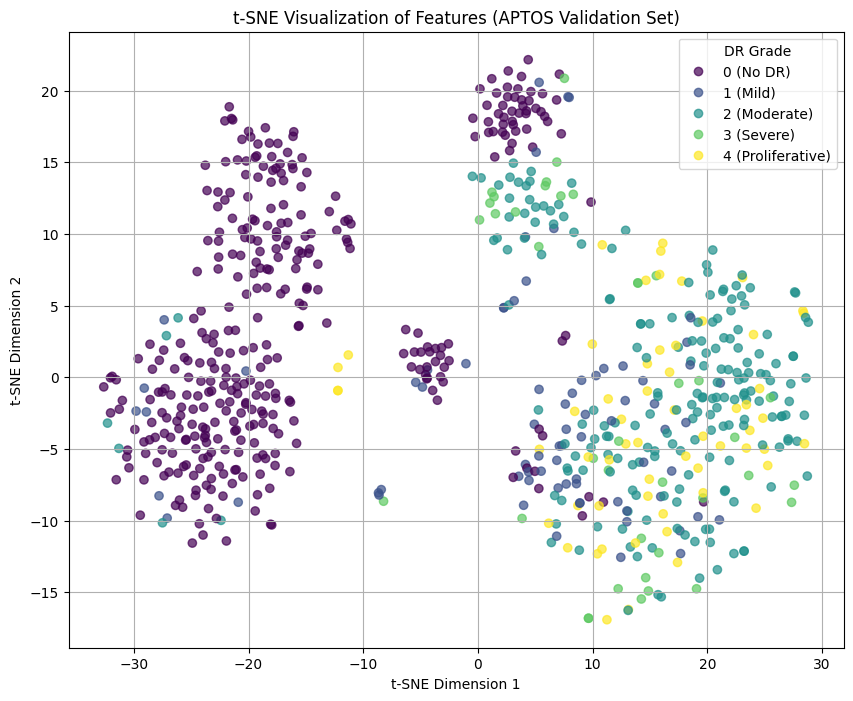


--- بصری‌سازی t-SNE به پایان رسید ---


In [ ]:
# --- 4. Model Evaluation and t-SNE ---

# Plot accuracy and loss graphs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs (Fine-tune)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'], label='Training Loss')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (Fine-tune)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predict on the validation set
print("\n--- Final Model Evaluation ---")
val_predictions = model.predict(validation_dataset)
predicted_classes = np.argmax(val_predictions, axis=1)
true_classes = val_df['diagnosis'].values

if len(predicted_classes) != len(true_classes):
    min_len = min(len(predicted_classes), len(true_classes))
    predicted_classes = predicted_classes[:min_len]
    true_classes = true_classes[:min_len]

print("\nFinal Classification Report:")
print(classification_report(true_classes, predicted_classes))

conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(NUM_CLASSES)],
            yticklabels=[str(i) for i in range(NUM_CLASSES)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

kappa_score = cohen_kappa_score(true_classes, predicted_classes, weights='quadratic')
print(f"\nFinal Cohen's Kappa Score (Quadratic): {kappa_score:.4f}")


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# --- Prepare Data for ROC Analysis ---
# Convert true labels to binary format (One-Hot Encoding)
label_binarizer = LabelBinarizer().fit(true_classes)
y_real_binarized = label_binarizer.transform(true_classes)

y_pred_probabilities = val_predictions

# --- Calculate ROC and AUC for each class ---
plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_real_binarized[:, i], y_pred_probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"Class {i} (AUC = {roc_auc:.2f})",
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.title("Receiver Operating Characteristic (ROC) Curve per Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\nAUC Scores per Class:")
for i in range(NUM_CLASSES):
    print(f"Class {i}: {auc(roc_curve(y_real_binarized[:, i], y_pred_probabilities[:, i])[0], roc_curve(y_real_binarized[:, i], y_pred_probabilities[:, i])[1]):.4f}")


# --- t-SNE for Visualization ---
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model as KerasModel
print("\n--- Starting Feature Visualization with t-SNE ---")

try:
    feature_extractor = KerasModel(inputs=model.input, outputs=model.get_layer('global_average_pooling2d').output)
except ValueError:
    feature_extractor = KerasModel(inputs=model.input, outputs=model.layers[-3].output)

val_features = feature_extractor.predict(validation_dataset)
val_labels_tsne = val_df['diagnosis'].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(val_features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=val_labels_tsne, cmap='viridis', alpha=0.7)
classes_names = ['0 (No DR)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Proliferative)']
plt.legend(handles=scatter.legend_elements()[0], labels=classes_names, title="DR Grade") # Use classes_names
plt.title('t-SNE Visualization of Features (APTOS Validation Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

print("\n--- t-SNE Visualization Completed ---")

##  Model Interpretability and Clinical Explainability (Grad-CAM)

In medical imaging, high accuracy is not enough; deep learning models must not operate as "black boxes." For a clinician to trust an AI system, they must understand *why* the model made a specific diagnosis. If a model classifies an image as "Severe DR," we need visual proof that it is actually looking at pathological features (like hemorrhages or exudates) rather than overfitting to irrelevant artifacts (like camera lighting or dust on the lens).

This cell implements **Grad-CAM (Gradient-weighted Class Activation Mapping)** to provide visual explainability for our CNN's predictions.

**How Grad-CAM Works in this Pipeline:**

1. **Feature Extraction Hook:** The algorithm taps into the final convolutional layer of our ResNet50 base (`conv5_block3_out`). This specific layer is chosen because it contains the highest-level spatial features before they are flattened into 1D vectors.
2. **Gradient Calculation (`tf.GradientTape`):** It computes the gradient of the target predicted class with respect to the feature maps of that final convolutional layer. This mathematically answers the question: *"Which specific spatial features had the largest influence on predicting this specific DR grade?"*
3. **Weighting and Heatmap Generation:** The gradients are globally pooled to calculate an importance weight for each channel. The feature maps are multiplied by these weights, and a **ReLU activation** is applied to filter out negative influences, isolating only the pixels that positively contributed to the diagnosis.
4. **Visual Overlay:** The resulting low-resolution heatmap is scaled up and superimposed over the original high-resolution retinal image using a color map (where red/hot indicates the highest model attention, and blue/cold indicates ignored areas).

By executing this algorithm on a validation sample, we generate a highly interpretable visual report that bridges the gap between deep learning mathematics and clinical ophthalmology.


--- شروع Grad-CAM برای تفسیر مدل ---


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_358']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipython-input-2915886376.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


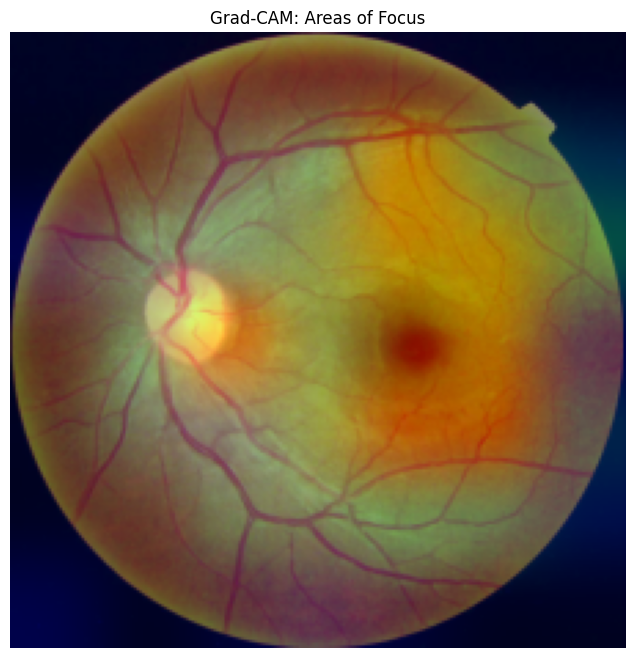


--- Grad-CAM با موفقیت اجرا شد ---


In [ ]:
# --- Add Grad-CAM for visualizing model's focus points ---
print("\n--- Starting Grad-CAM for model interpretation ---")

import matplotlib.cm as cm # For creating colormaps
from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.applications.resnet50 import preprocess_input

# Main Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    # 1. Build a model that has the output of the final convolutional layer and the final predictions
    grad_model = KerasModel(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Calculate gradients of the predicted class for the target class with respect to the convolutional layer output
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Gradients of the target class output with respect to the final convolutional layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Average the gradients for each channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Weight the final convolutional layer output with the pooled gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Apply ReLU and normalize to generate the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 7. Function to display heatmap on the original image
def display_gradcam(img_path, heatmap, alpha=0.4):
    """
    Superimposes the heatmap on the original image and displays it.
    """
    # Load the original image
    img = tf.keras.utils.load_img(img_path)
    img = tf.keras.utils.img_to_array(img)

    # Resize heatmap to the size of the original image
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to RGB
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the original image on the heatmap
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM: Areas of Focus")
    plt.axis("off")
    plt.show()


img_to_analyze_id = val_df['id_code'].iloc[0]
img_to_analyze_path = os.path.join(preprocessed_train_image_dir, img_to_analyze_id)

# 2. Load and prepare the image for the model
img_array = tf.keras.utils.load_img(img_to_analyze_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
img_array = tf.keras.utils.img_to_array(img_array)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# 3. Name of the final convolutional layer of ResNet50
last_conv_layer_name = "conv5_block3_out"

# 4. Generate heatmap
# We use the 'model' variable where your model is stored.
try:
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    # 5. Display image with heatmap
    display_gradcam(img_to_analyze_path, heatmap)
    print("\n--- Grad-CAM executed successfully ---")

except Exception as e:
    print(f"\nError executing Grad-CAM: {e}")
    print("Please ensure the model and correct convolutional layer name exist.")